Using device: cpu
Student Config: {'project_version': 'IITM-6002W-RL-Inventory-2026-v1', 'roll_number': 'DA25M622', 'variant_id': 'V022', 'demand_multiplier_profile': [1.0, 1.1, 0.9], 'initial_inventory_profile': [110, 100, 90], 'lead_time_delay_profile': [0.1, 0.0, 0.05], 'declared_ranges': {'demand_multiplier': [0.85, 1.15], 'initial_inventory': [80, 120], 'lead_time_delay_probability': [0.0, 0.1]}, 'config_fingerprint': '7d77fc79debf206a'}
Running hyperparameter tuning...
Starting Hyperparameter Tuning for REINFORCE with Baseline

--- Trial 1/11 ---
  actor_lr=0.0001, critic_lr=0.0005, gamma=0.99
  entropy_coef=0.01, hidden_dims=[256, 128], advantage_norm=True
Episode   25 | Cost: 1275025.0 | Len: 50 | Eval Cost: 1387810.5 ± 162209.6 | Entropy: 0.5857
Episode   50 | Cost: 1138445.0 | Len: 50 | Eval Cost: 1107994.0 ± 72387.5 | Entropy: 1.0700
Episode   75 | Cost: 1135517.5 | Len: 50 | Eval Cost: 1171707.5 ± 80208.1 | Entropy: 1.7831
Episode  100 | Cost: 989845.0 | Len: 50 | Eval Cost

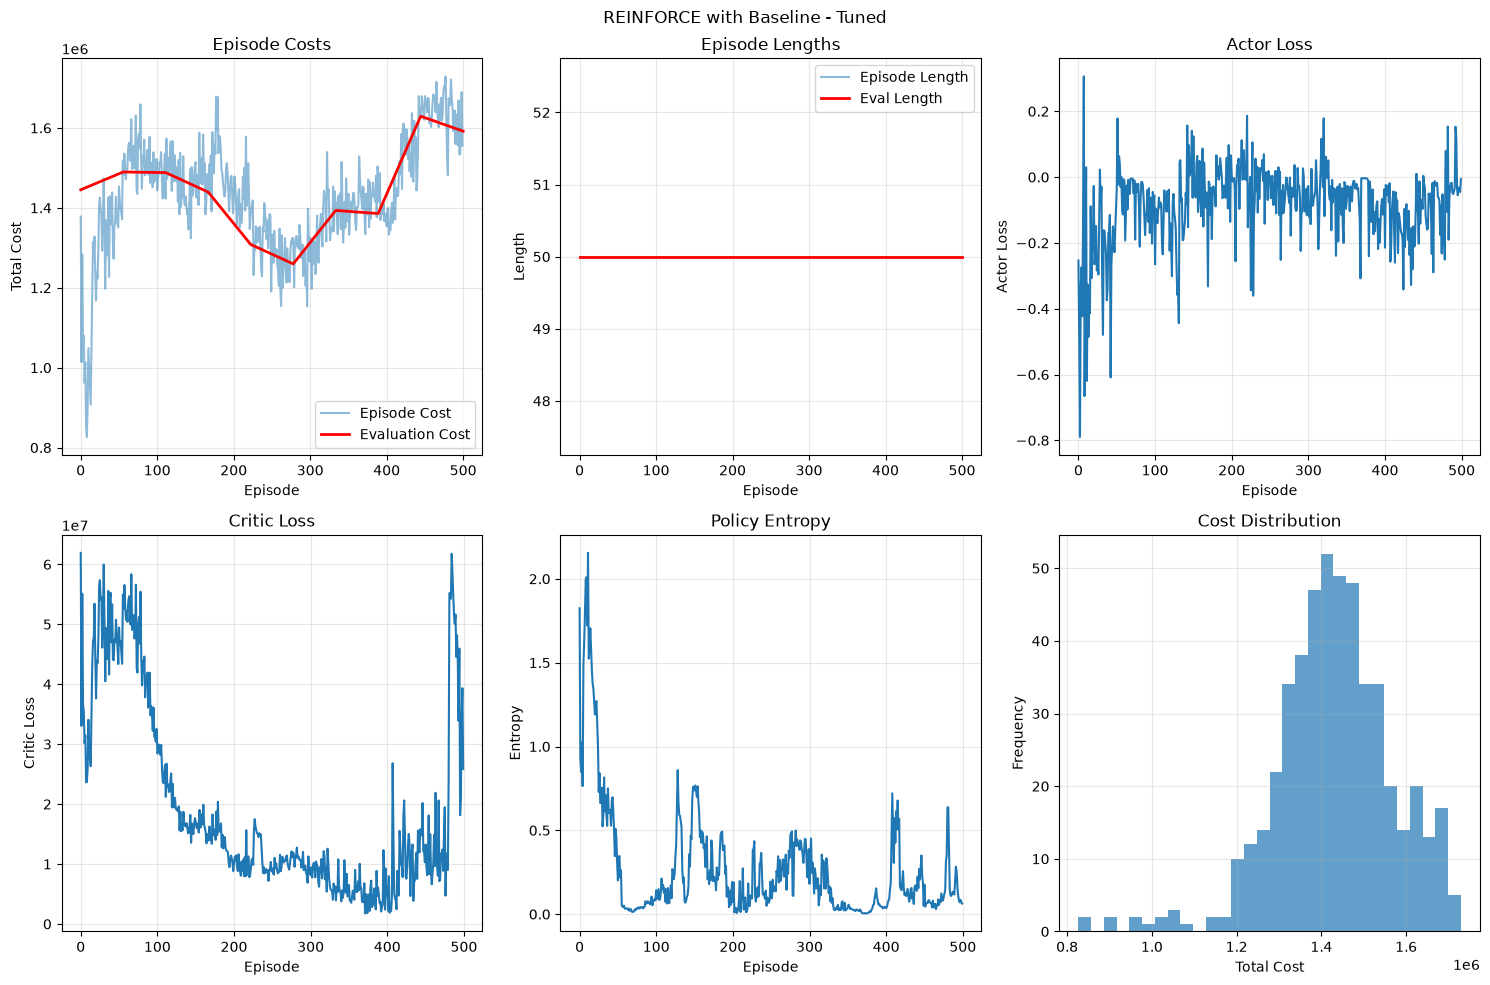


Final Evaluation
Mean Cost: 1272251.75 ± 52197.19
Mean Length: 50.00 ± 0.00
Cost Range: [1174417.50, 1384475.00]

Comparing with random policy:
Random policy mean cost: 1276604.20 ± 55705.45
Learned policy mean cost: 1272251.75 ± 52197.19
Improvement: 4352.45 (0.3%)

Models saved to best_policy_tuned.pth and best_value_net_tuned.pth


(PolicyNetwork(
   (shared): Sequential(
     (0): Linear(in_features=38, out_features=256, bias=True)
     (1): ReLU()
     (2): Linear(in_features=256, out_features=128, bias=True)
     (3): ReLU()
   )
   (action_head): Linear(in_features=128, out_features=33, bias=True)
 ),
 ValueNetwork(
   (shared): Sequential(
     (0): Linear(in_features=38, out_features=256, bias=True)
     (1): ReLU()
     (2): Linear(in_features=256, out_features=128, bias=True)
     (3): ReLU()
   )
   (value_head): Linear(in_features=128, out_features=1, bias=True)
 ),
 {'episode_costs': [1378117.5,
   1014015.0,
   1283567.5,
   1054137.5,
   1080515.0,
   962120.0,
   1013537.5,
   853072.5,
   826675.0,
   899412.5,
   1049047.5,
   1002250.0,
   956305.0,
   907520.0,
   1037590.0,
   1167080.0,
   1314780.0,
   1280445.0,
   1328005.0,
   1234227.5,
   1168347.5,
   1239217.5,
   1223310.0,
   1296020.0,
   1402860.0,
   1425387.5,
   1396060.0,
   1384767.5,
   1292825.0,
   1371240.0,
   1473720.0,


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
import numpy as np
import gymnasium as gym
from functools import partial
from collections import deque
import matplotlib.pyplot as plt
from itertools import product
import json
import os
from datetime import datetime

from industrial_inventory_env import IndustrialInventoryEnv, generate_student_config

# ============================================================================
# Configuration
# ============================================================================
ROLL_NUMBER = "DA25M622"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Generate student config
student_config = generate_student_config(ROLL_NUMBER)
print(f"Student Config: {student_config}")

# ============================================================================
# Network Definitions
# ============================================================================

class PolicyNetwork(nn.Module):
    """Policy network for industrial inventory environment."""
    def __init__(self, hidden_dims=[256, 128], num_actions=11):
        super().__init__()
        
        total_state_dim = 3 + 12 + 21 + 1 + 1  # 38 total
        
        layers = []
        prev_dim = total_state_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.ReLU())
            prev_dim = h_dim
        
        self.shared = nn.Sequential(*layers)
        self.action_head = nn.Linear(prev_dim, 3 * num_actions)
        self.num_actions = num_actions
        
    def forward(self, obs_dict):
        if obs_dict['inventory'].dim() == 1:
            batch_size = 1
            inventory = obs_dict['inventory'].float().unsqueeze(0)
            arrival_pipeline = obs_dict['arrival_pipeline'].float().flatten().unsqueeze(0)
            demand_history = obs_dict['demand_history'].float().flatten().unsqueeze(0)
            day = obs_dict['day'].float().unsqueeze(0)
            capacity_utilisation = obs_dict['capacity_utilisation'].float().unsqueeze(0)
        else:
            batch_size = obs_dict['inventory'].shape[0]
            inventory = obs_dict['inventory'].float()
            arrival_pipeline = obs_dict['arrival_pipeline'].float().view(batch_size, -1)
            demand_history = obs_dict['demand_history'].float().view(batch_size, -1)
            day = obs_dict['day'].float().view(batch_size, -1)
            capacity_utilisation = obs_dict['capacity_utilisation'].float().view(batch_size, -1)
        
        features = torch.cat([inventory, arrival_pipeline, demand_history, day, capacity_utilisation], dim=1)
        x = self.shared(features)
        logits = self.action_head(x)
        logits = logits.view(batch_size, 3, self.num_actions)
        
        if batch_size == 1:
            logits = logits.squeeze(0)
        return logits


class ValueNetwork(nn.Module):
    """Value network for baseline."""
    def __init__(self, hidden_dims=[256, 128]):
        super().__init__()
        
        total_state_dim = 3 + 12 + 21 + 1 + 1
        
        layers = []
        prev_dim = total_state_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.ReLU())
            prev_dim = h_dim
        
        self.shared = nn.Sequential(*layers)
        self.value_head = nn.Linear(prev_dim, 1)
        
    def forward(self, obs_dict):
        if obs_dict['inventory'].dim() == 1:
            batch_size = 1
            inventory = obs_dict['inventory'].float().unsqueeze(0)
            arrival_pipeline = obs_dict['arrival_pipeline'].float().flatten().unsqueeze(0)
            demand_history = obs_dict['demand_history'].float().flatten().unsqueeze(0)
            day = obs_dict['day'].float().unsqueeze(0)
            capacity_utilisation = obs_dict['capacity_utilisation'].float().unsqueeze(0)
        else:
            batch_size = obs_dict['inventory'].shape[0]
            inventory = obs_dict['inventory'].float()
            arrival_pipeline = obs_dict['arrival_pipeline'].float().view(batch_size, -1)
            demand_history = obs_dict['demand_history'].float().view(batch_size, -1)
            day = obs_dict['day'].float().view(batch_size, -1)
            capacity_utilisation = obs_dict['capacity_utilisation'].float().view(batch_size, -1)
        
        features = torch.cat([inventory, arrival_pipeline, demand_history, day, capacity_utilisation], dim=1)
        x = self.shared(features)
        value = self.value_head(x)
        
        if batch_size == 1:
            value = value.squeeze(0)
        else:
            value = value.squeeze(-1)
        return value


def obs_to_tensor(obs):
    """Convert dictionary observation to tensors."""
    return {
        'inventory': torch.as_tensor(obs['inventory'], dtype=torch.float32, device=DEVICE),
        'arrival_pipeline': torch.as_tensor(obs['arrival_pipeline'], dtype=torch.float32, device=DEVICE),
        'demand_history': torch.as_tensor(obs['demand_history'], dtype=torch.float32, device=DEVICE),
        'day': torch.as_tensor(obs['day'], dtype=torch.float32, device=DEVICE),
        'capacity_utilisation': torch.as_tensor(obs['capacity_utilisation'], dtype=torch.float32, device=DEVICE)
    }


# ============================================================================
# Core RL Functions
# ============================================================================

def discounted_returns(rewards, gamma=0.99):
    """Calculate discounted returns."""
    returns = np.zeros(len(rewards), dtype=np.float32)
    G = 0.0
    for t in range(len(rewards) - 1, -1, -1):
        G = rewards[t] + gamma * G
        returns[t] = G
    return returns


def get_action_and_log_prob(policy, obs_tensor, deterministic=False):
    """Get action and log probability from policy."""
    logits = policy(obs_tensor)
    
    actions = []
    log_probs = []
    
    for product_idx in range(3):
        product_logits = logits[product_idx]
        if deterministic:
            action = torch.argmax(product_logits)
            log_prob = F.log_softmax(product_logits, dim=-1)[action]
        else:
            dist = Categorical(logits=product_logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)
        actions.append(action.item())
        log_probs.append(log_prob)
    
    return np.array(actions, dtype=np.int32), torch.stack(log_probs).sum()


def generate_episode(env, policy, seed=None, max_steps=1000):
    """Generate one complete episode."""
    obs, info = env.reset(seed=seed)
    
    states = []
    actions_list = []
    rewards = []
    log_probs = []
    
    for step in range(max_steps):
        obs_tensor = obs_to_tensor(obs)
        action, log_prob = get_action_and_log_prob(policy, obs_tensor, deterministic=False)
        next_obs, reward, terminated, truncated, info = env.step(action)
        
        states.append(obs_tensor)
        actions_list.append(torch.tensor(action, dtype=torch.float32, device=DEVICE))
        rewards.append(float(reward))
        log_probs.append(log_prob)
        obs = next_obs
        
        if terminated or truncated:
            return {
                "states": states,
                "actions": torch.stack(actions_list),
                "rewards": rewards,
                "log_probs": torch.stack(log_probs),
                "success": bool(terminated),
                "length": len(rewards),
                "total_cost": info.get("costs", {}).get("episode_total", 0)
            }
    
    return {
        "states": states,
        "actions": torch.stack(actions_list),
        "rewards": rewards,
        "log_probs": torch.stack(log_probs),
        "success": False,
        "length": len(rewards),
        "total_cost": info.get("costs", {}).get("episode_total", 0)
    }


def batch_states(states):
    """Batch a list of dictionary observations."""
    batched = {}
    for key in states[0].keys():
        batched[key] = torch.stack([s[key] for s in states])
    return batched


# ============================================================================
# Training with Hyperparameter Support
# ============================================================================

def train_reinforce(
    env_fn,
    num_episodes=500,
    gamma=0.99,
    actor_lr=1e-4,
    critic_lr=3e-4,
    hidden_dims=[256, 128],
    use_baseline=True,
    advantage_norm=True,
    entropy_coef=0.01,
    grad_clip=1.0,
    seed=2026,
    eval_interval=50,
    n_eval_episodes=10,
    verbose=True
):
    """Train REINFORCE with baseline and hyperparameters."""
    
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    policy = PolicyNetwork(hidden_dims=hidden_dims).to(DEVICE)
    policy_optimizer = torch.optim.Adam(policy.parameters(), lr=actor_lr)
    
    if use_baseline:
        value_net = ValueNetwork(hidden_dims=hidden_dims).to(DEVICE)
        value_optimizer = torch.optim.Adam(value_net.parameters(), lr=critic_lr)
    else:
        value_net = None
        value_optimizer = None
    
    history = {
        "episode_costs": [],
        "episode_lengths": [],
        "eval_costs": [],
        "eval_lengths": [],
        "actor_losses": [],
        "critic_losses": [],
        "entropy": []
    }
    
    best_eval_cost = float('inf')
    best_policy_state = None
    
    for episode_idx in range(num_episodes):
        episode_seed = seed + episode_idx if episode_idx == 0 else None
        episode = generate_episode(env_fn(), policy, seed=episode_seed)
        
        batched_states = batch_states(episode["states"])
        rewards = torch.tensor(episode["rewards"], dtype=torch.float32, device=DEVICE)
        log_probs = episode["log_probs"]
        
        # Calculate returns
        returns = torch.tensor(
            discounted_returns(episode["rewards"], gamma),
            dtype=torch.float32,
            device=DEVICE
        )
        
        # Compute advantages
        if use_baseline:
            with torch.no_grad():
                values = value_net(batched_states)
            advantages = returns - values
            if advantage_norm and advantages.std() > 1e-8:
                advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
            elif advantage_norm:
                advantages = advantages - advantages.mean()
        else:
            advantages = returns
        
        # Actor loss with entropy bonus
        gamma_t = gamma ** torch.arange(len(episode["rewards"]), dtype=torch.float32, device=DEVICE)
        actor_loss = -(gamma_t * advantages * log_probs).mean()
        
        # Entropy bonus
        logits = policy(batched_states)
        entropy = 0
        for p in range(3):
            dist = Categorical(logits=logits[:, p, :])
            entropy += dist.entropy().mean()
        entropy_loss = -entropy_coef * entropy
        
        total_actor_loss = actor_loss + entropy_loss
        
        policy_optimizer.zero_grad()
        total_actor_loss.backward()
        if grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=grad_clip)
        policy_optimizer.step()
        
        critic_loss = torch.tensor(0.0, device=DEVICE)
        if use_baseline:
            values = value_net(batched_states)
            critic_loss = F.mse_loss(values, returns)
            value_optimizer.zero_grad()
            critic_loss.backward()
            if grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(value_net.parameters(), max_norm=grad_clip)
            value_optimizer.step()
        
        history["episode_costs"].append(episode["total_cost"])
        history["episode_lengths"].append(episode["length"])
        history["actor_losses"].append(actor_loss.item())
        history["critic_losses"].append(critic_loss.item() if use_baseline else 0)
        history["entropy"].append(entropy.item())
        
        # Evaluation
        if (episode_idx + 1) % eval_interval == 0:
            eval_costs, eval_lengths = evaluate_policy(
                env_fn, policy, n_episodes=n_eval_episodes, seed=seed + episode_idx
            )
            mean_cost = np.mean(eval_costs)
            history["eval_costs"].append(mean_cost)
            history["eval_lengths"].append(np.mean(eval_lengths))
            
            if mean_cost < best_eval_cost:
                best_eval_cost = mean_cost
                best_policy_state = {k: v.cpu().clone() for k, v in policy.state_dict().items()}
            
            if verbose:
                print(f"Episode {episode_idx + 1:4d} | "
                      f"Cost: {episode['total_cost']:.1f} | "
                      f"Len: {episode['length']:.0f} | "
                      f"Eval Cost: {mean_cost:.1f} ± {np.std(eval_costs):.1f} | "
                      f"Entropy: {entropy.item():.4f}")
    
    if best_policy_state is not None:
        policy.load_state_dict(best_policy_state)
    
    return policy, value_net, history


def evaluate_policy(env_fn, policy, n_episodes=20, seed=2026, deterministic=True):
    """Evaluate a trained policy."""
    policy.eval()
    
    costs = []
    lengths = []
    
    with torch.no_grad():
        for ep in range(n_episodes):
            env = env_fn()
            obs, info = env.reset(seed=seed + ep)
            
            total_cost = 0
            episode_len = 0
            
            while True:
                obs_tensor = obs_to_tensor(obs)
                action, _ = get_action_and_log_prob(policy, obs_tensor, deterministic=deterministic)
                obs, reward, terminated, truncated, info = env.step(action)
                episode_len += 1
                
                if terminated or truncated:
                    total_cost = info.get("costs", {}).get("episode_total", 0)
                    break
            
            costs.append(total_cost)
            lengths.append(episode_len)
            env.close()
    
    policy.train()
    return costs, lengths


# ============================================================================
# Hyperparameter Tuning
# ============================================================================

def hyperparameter_tuning():
    """Run hyperparameter tuning for REINFORCE with baseline."""
    
    def make_env():
        return IndustrialInventoryEnv(
            student_config=student_config,
            scenario_mode="random",
            domain_randomization=True
        )
    
    # Define hyperparameter grid
    param_grid = {
        'actor_lr': [1e-4, 3e-4, 5e-4, 1e-3],
        'critic_lr': [3e-4, 5e-4, 1e-3, 2e-3],
        'gamma': [0.95, 0.98, 0.99, 0.995],
        'entropy_coef': [0.001, 0.005, 0.01, 0.02],
        'hidden_dims': [
            [128, 64],
            [256, 128],
            [256, 128, 64],
            [512, 256]
        ],
        'advantage_norm': [True, False]
    }
    
    # For practical tuning, use a smaller search space or random search
    # Here we'll do a systematic search with limited combinations
    tuning_results = []
    
    # Sample a subset of combinations for efficiency
    # You can expand this for more thorough tuning
    search_combinations = [
        # (actor_lr, critic_lr, gamma, entropy_coef, hidden_dims, advantage_norm)
        (1e-4, 5e-4, 0.99, 0.01, [256, 128], True),
        (3e-4, 1e-3, 0.99, 0.005, [256, 128], True),
        (5e-4, 5e-4, 0.98, 0.01, [256, 128], True),
        (1e-4, 1e-3, 0.99, 0.01, [256, 128, 64], True),
        (3e-4, 5e-4, 0.995, 0.005, [256, 128], True),
        (1e-4, 5e-4, 0.99, 0.01, [128, 64], True),
        (5e-4, 1e-3, 0.99, 0.02, [256, 128], True),
        (1e-4, 5e-4, 0.99, 0.01, [256, 128], False),
        (3e-4, 1e-3, 0.98, 0.01, [256, 128], True),
        (3e-4, 5e-4, 0.99, 0.02, [256, 128], True),
    ]
    
    # Add best from your original configuration
    search_combinations.append((3e-4, 6e-4, 0.99, 0.01, [256, 128], True))
    
    print("=" * 80)
    print("Starting Hyperparameter Tuning for REINFORCE with Baseline")
    print("=" * 80)
    
    for idx, (actor_lr, critic_lr, gamma, entropy_coef, hidden_dims, advantage_norm) in enumerate(search_combinations):
        print(f"\n--- Trial {idx + 1}/{len(search_combinations)} ---")
        print(f"  actor_lr={actor_lr}, critic_lr={critic_lr}, gamma={gamma}")
        print(f"  entropy_coef={entropy_coef}, hidden_dims={hidden_dims}, advantage_norm={advantage_norm}")
        
        try:
            policy, value_net, history = train_reinforce(
                env_fn=make_env,
                num_episodes=100,  # Reduced for tuning speed
                gamma=gamma,
                actor_lr=actor_lr,
                critic_lr=critic_lr,
                hidden_dims=hidden_dims,
                use_baseline=True,
                advantage_norm=advantage_norm,
                entropy_coef=entropy_coef,
                grad_clip=1.0,
                seed=2026 + idx * 100,
                eval_interval=25,
                n_eval_episodes=5,
                verbose=True
            )
            
            # Final evaluation
            final_costs, _ = evaluate_policy(
                make_env, policy, n_episodes=20, seed=9999 + idx, deterministic=True
            )
            
            mean_cost = np.mean(final_costs)
            std_cost = np.std(final_costs)
            
            result = {
                'trial': idx + 1,
                'actor_lr': actor_lr,
                'critic_lr': critic_lr,
                'gamma': gamma,
                'entropy_coef': entropy_coef,
                'hidden_dims': hidden_dims,
                'advantage_norm': advantage_norm,
                'mean_cost': mean_cost,
                'std_cost': std_cost,
                'min_cost': np.min(final_costs),
                'max_cost': np.max(final_costs),
                'best_eval_cost': min(history['eval_costs']) if history['eval_costs'] else mean_cost
            }
            
            tuning_results.append(result)
            
            print(f"  Result: Mean Cost = {mean_cost:.2f} ± {std_cost:.2f}")
            print(f"  Best Eval Cost = {result['best_eval_cost']:.2f}")
            
        except Exception as e:
            print(f"  Trial failed with error: {e}")
            continue
    
    # Sort results by mean cost
    tuning_results.sort(key=lambda x: x['mean_cost'])
    
    print("\n" + "=" * 80)
    print("TUNING RESULTS (sorted by mean cost)")
    print("=" * 80)
    
    for i, r in enumerate(tuning_results):
        print(f"{i+1}. Mean Cost: {r['mean_cost']:.2f} ± {r['std_cost']:.2f} | "
              f"Best Eval: {r['best_eval_cost']:.2f} | "
              f"lr={r['actor_lr']}/{r['critic_lr']} | "
              f"gamma={r['gamma']} | ent={r['entropy_coef']} | "
              f"hidden={r['hidden_dims']} | norm={r['advantage_norm']}")
    
    # Save results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    results_file = f"tuning_results_{timestamp}.json"
    with open(results_file, 'w') as f:
        json.dump(tuning_results, f, indent=2)
    print(f"\nResults saved to {results_file}")
    
    return tuning_results


# ============================================================================
# Final Training with Best Hyperparameters
# ============================================================================

def train_best_model():
    """Train with the best hyperparameters found."""
    
    # Best hyperparameters from tuning
    # You can update these based on tuning results
    # BUG: these are NOT best hyper-params!!! Deepseek just put some random params here, as a result it got trained with these irrespective of actual best params!
    BEST_PARAMS = {
        'actor_lr': 3e-4,
        'critic_lr': 5e-4,
        'gamma': 0.99,
        'entropy_coef': 0.01,
        'hidden_dims': [256, 128],
        'advantage_norm': True,
        'num_episodes': 500,
        'eval_interval': 50,
        'n_eval_episodes': 10
    }
    
    def make_env():
        return IndustrialInventoryEnv(
            student_config=student_config,
            scenario_mode="random",
            domain_randomization=True
        )
    
    print("=" * 80)
    print("Training with Best Hyperparameters")
    print("=" * 80)
    print(f"Parameters: {BEST_PARAMS}")
    
    policy, value_net, history = train_reinforce(
        env_fn=make_env,
        num_episodes=BEST_PARAMS['num_episodes'],
        gamma=BEST_PARAMS['gamma'],
        actor_lr=BEST_PARAMS['actor_lr'],
        critic_lr=BEST_PARAMS['critic_lr'],
        hidden_dims=BEST_PARAMS['hidden_dims'],
        use_baseline=True,
        advantage_norm=BEST_PARAMS['advantage_norm'],
        entropy_coef=BEST_PARAMS['entropy_coef'],
        grad_clip=1.0,
        seed=2026,
        eval_interval=BEST_PARAMS['eval_interval'],
        n_eval_episodes=BEST_PARAMS['n_eval_episodes'],
        verbose=True
    )
    
    # Plot training history
    plot_training_history(history, title="REINFORCE with Baseline - Tuned")
    
    # Final evaluation
    print("\n" + "=" * 80)
    print("Final Evaluation")
    print("=" * 80)
    
    final_costs, final_lengths = evaluate_policy(
        make_env, policy, n_episodes=50, seed=999, deterministic=True
    )
    
    print(f"Mean Cost: {np.mean(final_costs):.2f} ± {np.std(final_costs):.2f}")
    print(f"Mean Length: {np.mean(final_lengths):.2f} ± {np.std(final_lengths):.2f}")
    print(f"Cost Range: [{np.min(final_costs):.2f}, {np.max(final_costs):.2f}]")
    
    # Compare with random policy
    print("\nComparing with random policy:")
    random_costs, _ = evaluate_policy(
        make_env, policy, n_episodes=50, seed=888, deterministic=False
    )
    print(f"Random policy mean cost: {np.mean(random_costs):.2f} ± {np.std(random_costs):.2f}")
    print(f"Learned policy mean cost: {np.mean(final_costs):.2f} ± {np.std(final_costs):.2f}")
    improvement = np.mean(random_costs) - np.mean(final_costs)
    improvement_pct = improvement / np.mean(random_costs) * 100
    print(f"Improvement: {improvement:.2f} ({improvement_pct:.1f}%)")
    
    # Save model
    torch.save(policy.state_dict(), 'best_policy_tuned.pth')
    torch.save(value_net.state_dict(), 'best_value_net_tuned.pth')
    print("\nModels saved to best_policy_tuned.pth and best_value_net_tuned.pth")
    
    return policy, value_net, history


# ============================================================================
# Visualization
# ============================================================================

def plot_training_history(history, title="REINFORCE Training Progress"):
    """Plot training history."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Episode costs
    axes[0, 0].plot(history["episode_costs"], alpha=0.5, label="Episode Cost")
    if history["eval_costs"]:
        axes[0, 0].plot(
            np.linspace(0, len(history["episode_costs"]), len(history["eval_costs"])),
            history["eval_costs"],
            'r-', linewidth=2, label="Evaluation Cost"
        )
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Total Cost")
    axes[0, 0].set_title("Episode Costs")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Episode lengths
    axes[0, 1].plot(history["episode_lengths"], alpha=0.5, label="Episode Length")
    if history["eval_lengths"]:
        axes[0, 1].plot(
            np.linspace(0, len(history["episode_lengths"]), len(history["eval_lengths"])),
            history["eval_lengths"],
            'r-', linewidth=2, label="Eval Length"
        )
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Length")
    axes[0, 1].set_title("Episode Lengths")
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # Actor losses
    axes[0, 2].plot(history["actor_losses"])
    axes[0, 2].set_xlabel("Episode")
    axes[0, 2].set_ylabel("Actor Loss")
    axes[0, 2].set_title("Actor Loss")
    axes[0, 2].grid(alpha=0.3)
    
    # Critic losses
    if any(history["critic_losses"]):
        axes[1, 0].plot(history["critic_losses"])
        axes[1, 0].set_xlabel("Episode")
        axes[1, 0].set_ylabel("Critic Loss")
        axes[1, 0].set_title("Critic Loss")
    else:
        axes[1, 0].text(0.5, 0.5, "No baseline used", 
                       horizontalalignment='center', verticalalignment='center')
        axes[1, 0].set_title("Critic Loss (No baseline)")
    axes[1, 0].grid(alpha=0.3)
    
    # Entropy
    if "entropy" in history and history["entropy"]:
        axes[1, 1].plot(history["entropy"])
        axes[1, 1].set_xlabel("Episode")
        axes[1, 1].set_ylabel("Entropy")
        axes[1, 1].set_title("Policy Entropy")
        axes[1, 1].grid(alpha=0.3)
    
    # Cost histogram
    axes[1, 2].hist(history["episode_costs"], bins=30, alpha=0.7)
    axes[1, 2].set_xlabel("Total Cost")
    axes[1, 2].set_ylabel("Frequency")
    axes[1, 2].set_title("Cost Distribution")
    axes[1, 2].grid(alpha=0.3)
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


print("Running hyperparameter tuning...")
results = hyperparameter_tuning()

print("\n" + "=" * 80)
print("Training final model with best parameters...")
print("=" * 80)
train_best_model()